In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [2]:
(x_train,_),(x_test,_) = mnist.load_data()

x_train = x_train.astype("float32")/255.
x_test = x_test.astype("float32")/255.

x_train = np.reshape(x_train,(-1,28,28,1))
x_test = np.reshape(x_test,(-1,28,28,1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor*np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

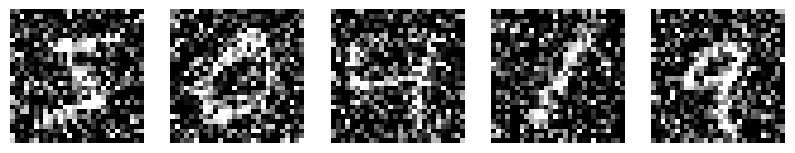

In [4]:
plt.figure(figsize=(10,3))

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28),cmap='gray')
    plt.axis("off")

plt.show()

In [5]:
input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder

x = Conv2D(64,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder = Model(input_img,decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [7]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 171s 361ms/step - loss: 0.1500 - val_loss: 0.1127
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 359ms/step - loss: 0.1093 - val_loss: 0.1094
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 168s 358ms/step - loss: 0.1043 - val_loss: 0.1022
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 165s 352ms/step - loss: 0.1019 - val_loss: 0.1000
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 349ms/step - loss: 0.1002 - val_loss: 0.0991
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 348ms/step - loss: 0.0991 - val_loss: 0.0978
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 346ms/step - loss: 0.0981 - val_loss: 0.0972
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 347ms/step - loss: 0.0973 - val_loss: 0.0964
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 355ms/step - loss: 0.0966 - val_loss: 0.0959
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 167s 355ms/step - loss: 0.0961 - val_loss: 0.0955


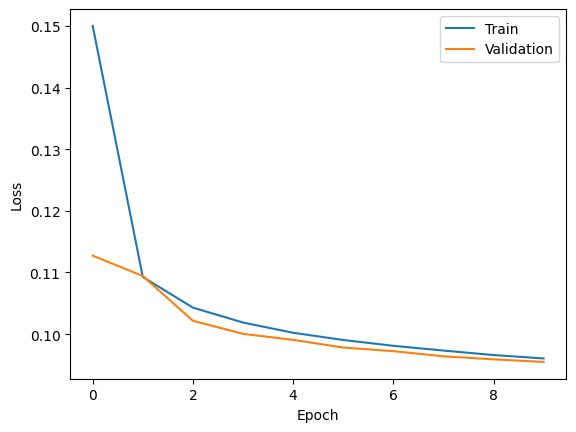

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [10]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


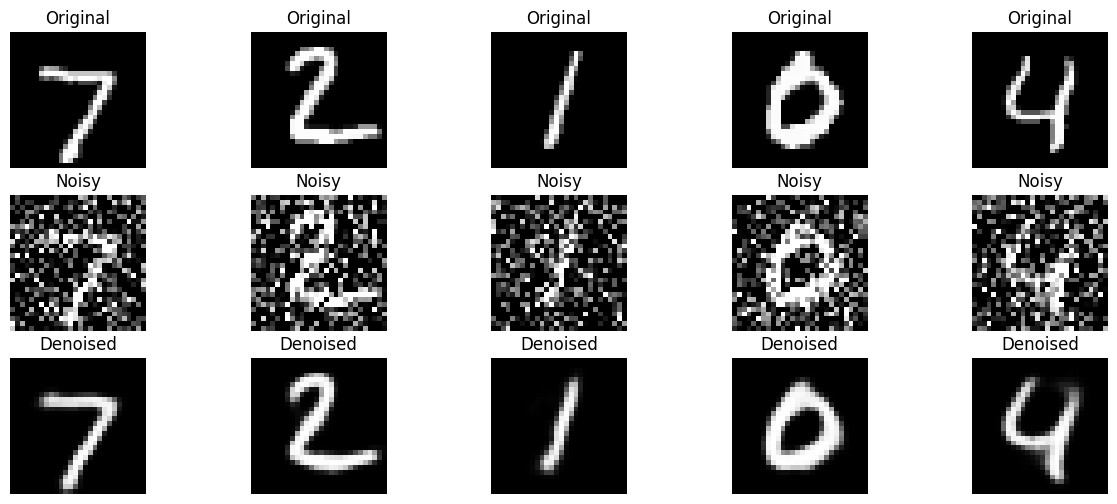

In [11]:
n = 5

plt.figure(figsize=(15,6))

for i in range(n):

    # Original
    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.axis("off")
    plt.title("Original")

    # Noisy
    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
    plt.axis("off")
    plt.title("Noisy")

    # Denoised
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis("off")
    plt.title("Denoised")

plt.show()

**conclusion**



A Convolutional Denoising Autoencoder was built using the MNIST dataset. Gaussian noise was added to the images, and the model successfully learned to reconstruct cleaner versions of the handwritten digits. The comparison between original, noisy, and reconstructed images demonstrates the effectiveness of Autoencoders for image denoising tasks.